In [1]:
library(Seurat)
library(scop)
library(Signac)
library(ggplot2)
set.seed(4180)
setwd("data/")
#########color
cols <- c("#444576", "#4682B4",
 "#AEDEEE","#FFA500",
 "#FFD790","#C65762","#FBDFDE",
 "#F6EFCF","#BCB99F")
pal <- colorRampPalette(cols)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Registered S3 method overwritten by 'scop':
  method             from  
  FoldChange.default Seurat

          ⬢          .        ⬡             ⬢     .
                     _____ _________  ____
                    / ___// ___/ __ ./ __ .
                   (__  )/ /__/ /_/ / /_/ /
                  /____/ .___/.____/ .___/
                                  /_/
      ⬢               .      ⬡        .          ⬢

------------------------------------------------------------
Version: 0.8.7 (2026-03-31 update)
Website: https://mengxu98.github.io/scop/

Python environment initialization is disabled
To enable it, set: options(scop_env_init = TRUE)

The message can be suppressed by: 
  suppressPackageStartupMessages(library(scop))
  or options(log_message.verbose = FALSE)
------------------------------------------

In [2]:
subsc.list <- readRDS("data/subsc.list.Rds")
names(subsc.list)

[1] "aCM"        "FB"         "EC"         "EndoCC"     "LEC"       
 [6] "SMC"        "Pericyte"   "Adipocyte"  "Neuronal"   "T"         
[11] "B"          "Macrophage" "DC"

In [3]:
EC <- subsc.list[[3]]
EC[["ATAC"]] <- readRDS("data/mHeart_ATAC.Rds")[,colnames(EC)][['ATAC']]

In [4]:
EC[["activity"]] <- readRDS("data/activity.Rds")[,colnames(EC)][['activity']]

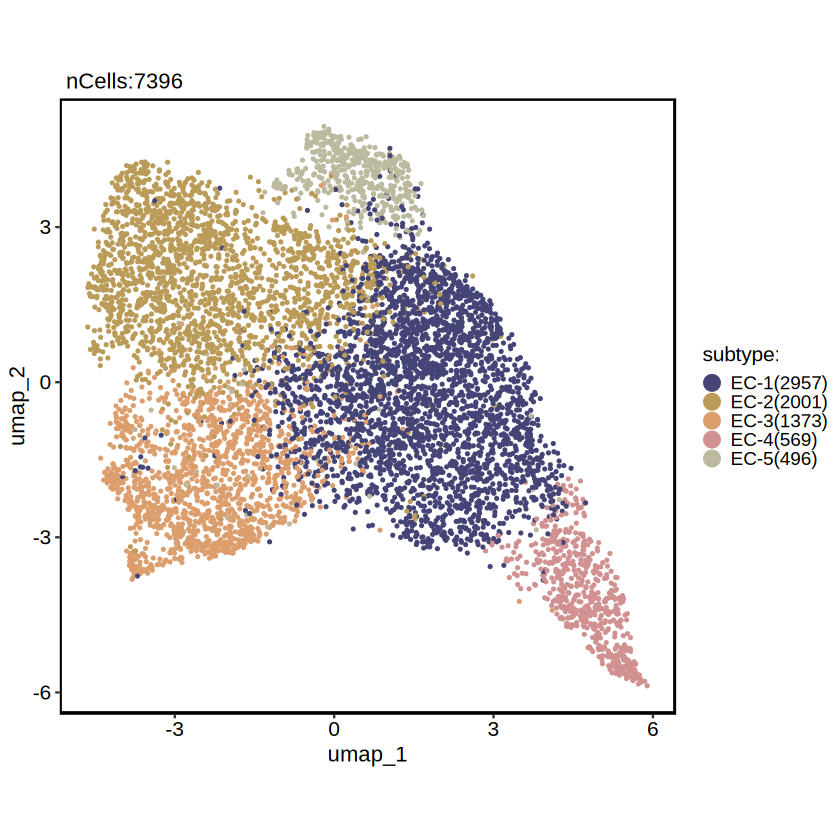

In [7]:
# fig3a
p <- CellDimPlot(
 srt = EC, group.by = "subtype",
 legend.position = "right", label_repel = T,
 label_point_size = 0.1, reduction = "umap",
 label = F, label_insitu = T,
 theme_use = "theme_scop",
 palcolor = pal(4), raster = F,
 label.fg = "black", label.bg = "grey95",
 label.bg.r = 0
)
ggsave(
 plot = p, filename = "fig3a_umap.pdf", path = "plot/figure3/",
 create.dir = TRUE, width = 4, height = 4
)
p

In [55]:
# fig3b
library(ComplexHeatmap)
library(dplyr)
DefaultAssay(EC) <- "RNA"
EC <- RunDEtest(EC,
 group.by = "subtype", fc.threshold = 1.2, cores = 4,
 assay = "RNA", only.pos = T, min.pct = 0.25
)
AllMarkers <- filter(
 EC@tools$DEtest_subtype$AllMarkers_wilcox,
 p_val_adj < 0.05,
 test_group_number == 1
)
AllMarkers <- AllMarkers %>%
 filter(p_val_adj < 0.05) %>%
 group_by(group1) %>%
 arrange(desc(avg_log2FC)) %>%
 slice_head(n = 50)
AllMarkers$label <- rownames(AllMarkers)
result <- AllMarkers %>%
 filter(p_val_adj < 0.05) %>%
 group_by(group1) %>%
 arrange(desc(avg_log2FC)) %>%
 slice_head(n = 5)
ave.dt <- scale(
 t(as.matrix(AverageExpression(EC[AllMarkers$gene, ],
 group.by = "subtype", assays = "RNA", layer = "data"
)$RNA)))
ave.dt <- ave.dt[, AllMarkers$gene]
ha <- HeatmapAnnotation(foo = anno_mark(
 at = as.numeric(result$label),
 labels = result$gene,
 labels_gp = gpar(fontsize = 10, rot = 45, fontface = "italic")
))
pdf("plot/figure3/fig3b_ECsubtype_markers.pdf", width = 6, height = 3) # save as pdf file
draw(Heatmap(ave.dt,
 cluster_columns = F,
 cluster_rows = F, col = c("grey80", "white", "#444576"),
 show_column_names = F,
 heatmap_legend_param = list(
 title = "Expression", at = c(-2, 0, 2),
 labels = c("Min", "", "Max")
 ),
 top_annotation = ha, row_names_side = "left",
 width = unit(10, "cm"), height = unit(4, "cm")
))
dev.off()

Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




ℹ [2026-05-01 22:31:05] Data type is log-normalized

ℹ [2026-05-01 22:31:05] Start differential expression test

ℹ [2026-05-01 22:31:05] Find all markers(wilcox) among [1] 5 groups...

ℹ [2026-05-01 22:31:05] Using 4 cores

⠙ [2026-05-01 22:31:05] Running for EC-1... [2/5] ■■■■        40% | ETA:  3s

✔ [2026-05-01 22:31:05] Completed 5 tasks in 4.2s



ℹ [2026-05-01 22:31:05] Building results

✔ [2026-05-01 22:31:10] Differential expression test completed

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


agg_record_3502b5606f1c7d 
                        2

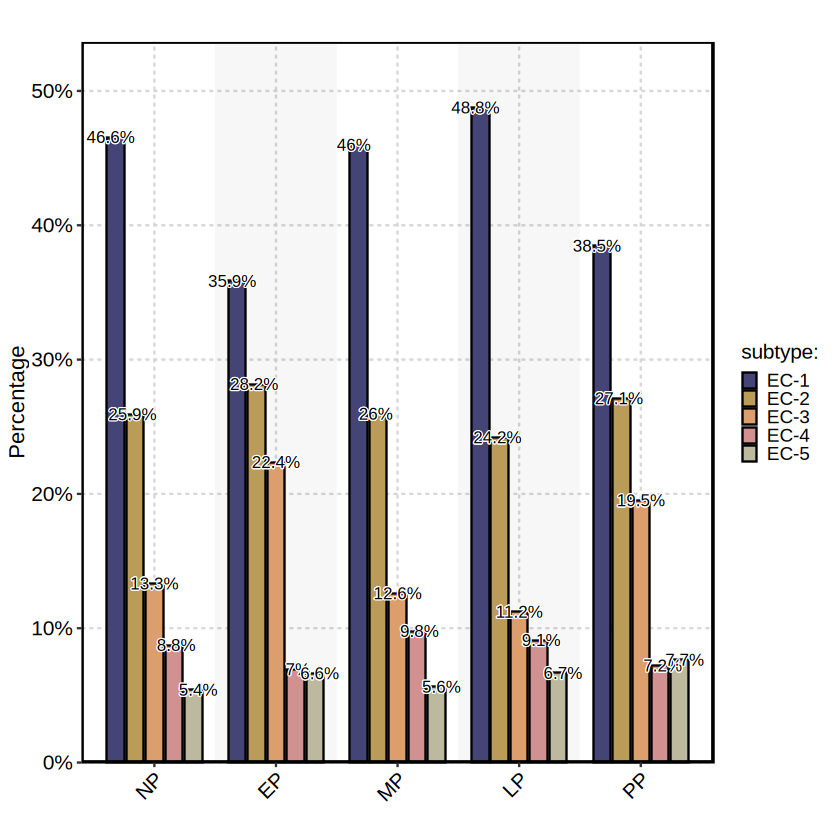

In [6]:
#fig2c
p <- CellStatPlot(EC, stat.by = "subtype", group.by = "group",
 label = T,palcolor = pal(4),position ="dodge",
 plot_type = "bar",xlab = '',ylab = 'Percentage')
p 
ggsave(plot = p,filename = "fig3c_ECstat.pdf",path = "plot/figure3/",
 create.dir = TRUE,width = 6,height = 3)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Registered S3 method overwritten by 'car':
  method           from
  na.action.merMod lme4

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.4 GiB”
`normalized_counts` is not a matrix, converting now.



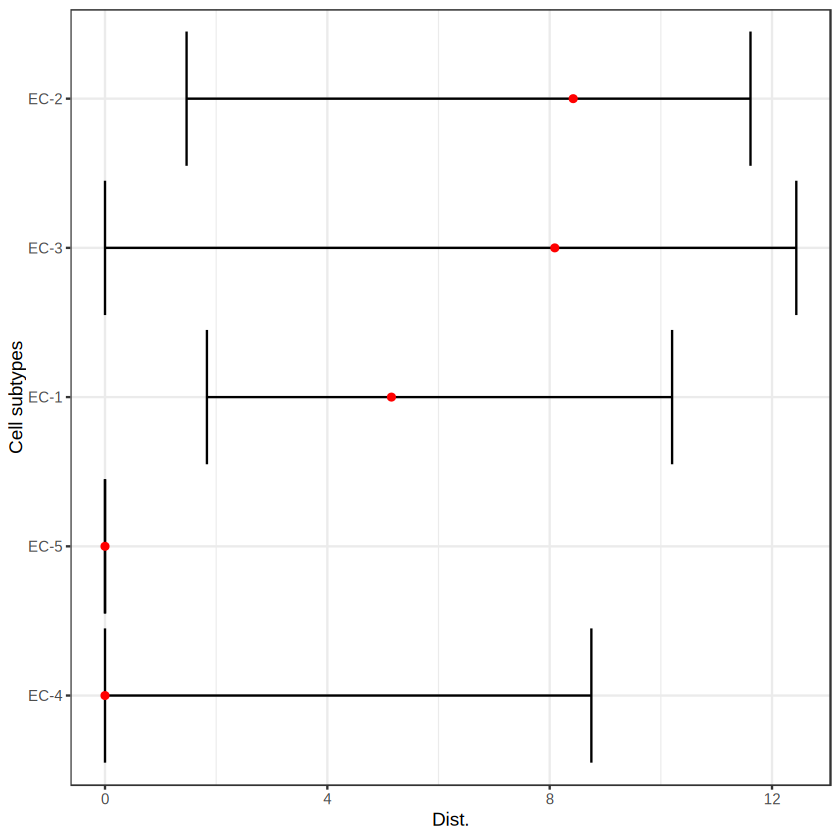

In [5]:
#fig3d
#scDist analysis
library(dplyr)
library(scDist)
library(ggplot2)
library(ggpubr)
######run Dist#################
sim <- list(Y=EC@assays$RNA$data %>% as.data.frame(),
 meta.data=EC@meta.data %>% as.data.frame())
out <- scDist(normalized_counts = sim$Y,
 meta.data = sim$meta.data,
 d = 20, # PCA
 fixed.effects = "group", #stim
 random.effects = c('orig.ident'), #batch/sample
 clusters="subtype" #
)
#plot scDist
p <- DistPlot(out)+theme_bw()+xlab(label = 'Cell subtypes')
p
ggsave("plot/figure3/fig3d_scDist.pdf", p, width = 3, height = 2.5 )

In [10]:
# fig3e
library(dplyr)
library(patchwork)
library(clusterProfiler)
samplegroup <- c("NP", "EP", "MP", "LP", "PP")
EC <- RunDEtest(EC, group.by = "subtype", only.pos = FALSE, fc.threshold = 1,min.pct = 0.1)
DEGs_group <- EC@tools$DEtest_subtype$AllMarkers_wilcox
allmarker <- DEGs_group %>%
 filter(p_val_adj < 0.05) %>%
 filter(pct.1 > 0.1) %>%
 filter(avg_log2FC > log2(1.5))
df_sig <- subset(allmarker)
group <- data.frame(
 gene = df_sig$gene,
 group = df_sig$group1
)
Gene_ID <- bitr(group$gene,
 fromType = "SYMBOL",
 toType = "ENTREZID",
 OrgDb = "org.Mm.eg.db"
)
data <- merge(Gene_ID, group, by.x = "SYMBOL", by.y = "gene")
levels(data$group) <- c('EC-1','EC-2','EC-3','EC-4','EC-5')
data_GO <- compareCluster(
 ENTREZID ~ group,
 data = data,
 fun = "enrichGO",
 OrgDb = "org.Mm.eg.db",
 ont = "BP",
 pAdjustMethod = "BH",
 pvalueCutoff = 0.05,
 qvalueCutoff = 0.05
)
res <- data_GO@compareClusterResult
for (i in 1:dim(res)[1]) {
 arr <- unlist(strsplit(as.character(res[i, "geneID"]), split = "/"))
 gene_names <- paste(unique(data$SYMBOL[data$ENTREZID %in% arr]), collapse = "/")
 res[i, "geneID"] <- gene_names
}
writexl::write_xlsx(res, "plot/figure3/fig3e_EC_subtype_GO.xlsx")



clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


ℹ [2026-05-07 23:30:16] Data type is log-normalized

ℹ [2026-05-07 23:30:16] Start differential expression test

ℹ [2026-05-07 23:30:16] Find all markers(wilcox) among [1] 5 groups...

ℹ [2026-05-07 23:30:16] Using 1 core

⠙ [2026-05-07 23:30:16] Running for EC-1 [1/5] ■■          20% | ETA:  4s

⠹ [2026-05-07 23:30:16] Running for EC-2 [2/5] ■■■■        40% | ETA:  3s

✔ [2026-05-07 23:30:16] Completed 5 tasks in 5.4s



ℹ [2026-05-07 23:30:16] Building results

✔ [2026-05-07 23:30:22] Differential expression test completed



'select()' returned 1:1 mapping between keys and c


EC-1 EC-2 EC-3 EC-4 EC-5 
   3    3    3    3    3 

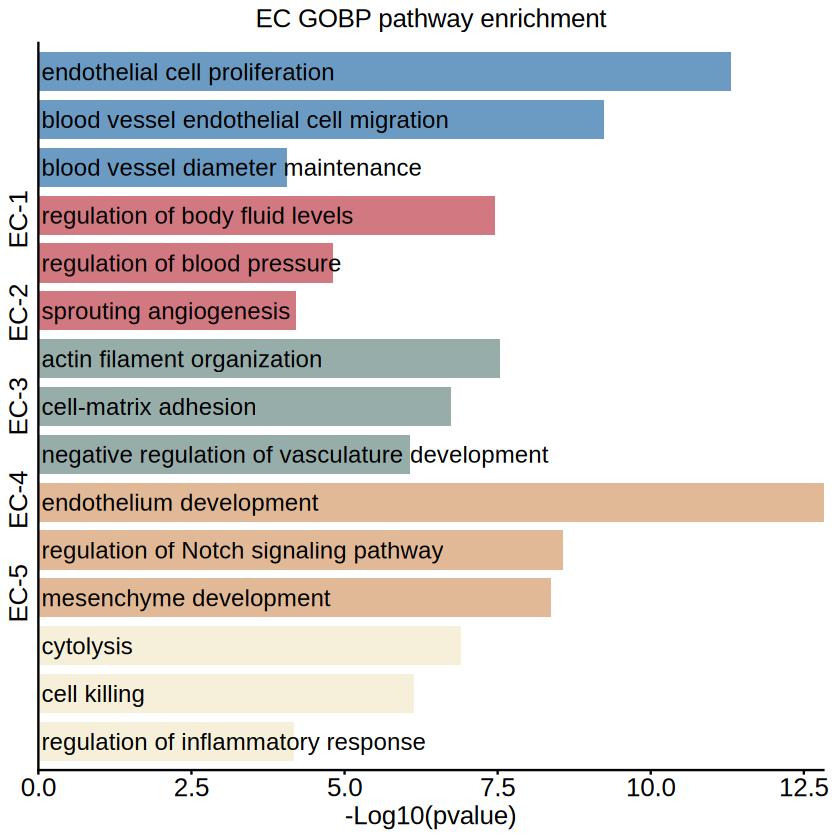

In [5]:
# plot
res <- openxlsx::read.xlsx("plot/figure3/fig3e_EC_subtype_GO.xlsx")
enrich <- subset(res, Description %in% c(
 "endothelial cell proliferation",
 "blood vessel endothelial cell migration",
 "blood vessel diameter maintenance"
) & group %in% "EC-1")
enrich <- rbind(enrich, subset(res, Description %in% c(
 "sprouting angiogenesis",
 "regulation of blood pressure",
 "regulation of body fluid levels"
) & group %in% "EC-2"))
enrich <- rbind(enrich, subset(res, Description %in% c(
 "negative regulation of vasculature development",
 "actin filament organization",
 "cell-matrix adhesion"
) & group %in% "EC-3"))
enrich <- rbind(enrich, subset(res, Description %in% c(
 "endothelium development",
 "regulation of Notch signaling pathway",
 "mesenchyme development"
) & group %in% "EC-4"))
enrich <- rbind(enrich, subset(res, Description %in% c(
 "regulation of inflammatory response",
 "cell killing",
 "cytolysis"
) & group %in% "EC-5"))
colnames(enrich) <- gsub("Groups", "Cluster", colnames(enrich))
dt <- enrich
dt$order <- gsub('EC-1','1',dt$Cluster)
dt$order <- gsub('EC-2','2',dt$order)
dt$order <- gsub('EC-3','3',dt$order)
dt$order <- gsub('EC-4','4',dt$order)
dt$order <- gsub('EC-5','5',dt$order)
dt <- dt[order(dt$pvalue), ]
dt <- dt[order(dt$order, decreasing = F), ]
table(dt$Cluster)
cols <- c("#4682B4", "#C65762", "#7C9895", "#DAA87C", "#F4EBD0")
pal <- colorRampPalette(cols)
# plot
dt$color <- factor(c(
 rep(pal(5)[3], each = 3),
 rep(pal(5)[2], each = 3),
 rep(pal(5)[1], each = 3),
 rep(pal(5)[4], each = 3),
 rep(pal(5)[5], each = 3)
), levels = pal(5))
dt$Description <- factor(dt$Description, levels = dt$Description)
dt$geneID <- paste(substr(dt$geneID, start = 1, stop = 40), "...", sep = "")
mytheme <- theme(
 axis.title = element_text(size = 15),
 axis.text = element_text(size = 15),
 axis.text.y = element_blank(), # remove y-axis pathway labels in the custom theme:
 axis.ticks.length.y = unit(0, "cm"),
 plot.title = element_text(size = 15, hjust = 0.5),
 legend.title = element_text(size = 13),
 legend.text = element_text(size = 11),
 plot.margin = margin(t = 5.5, r = 10, l = 5.5, b = 5.5)
)
p <- ggplot(data = dt, aes(
 x = -log10(pvalue),
 y = rev(Description),
 fill = Cluster
)) +
 scale_fill_manual(values = pal(5)) +
 geom_bar(stat = "identity", width = 0.8, alpha = 0.8) +
 scale_x_continuous(expand = c(0, 0)) + # align bar bottoms flush with the y-axis
 labs(
 x = "-Log10(pvalue)", y = "EC-5 EC-4 EC-3 EC-2 EC-1",
 title = "EC GOBP pathway enrichment"
 ) +
 # x = 0.61 numeric vector controlling the start position of text labels
 geom_text(
 size = 5,
 aes(x = 0.05, label = Description), hjust = 0
 ) + # hjust = 0,left-aligned
 theme_classic() +
 mytheme +
 NoLegend()
ggsave("plot/figure3/fig3e.pdf",p ,width = 5,height = 5)
p

In [71]:
rev(pal(4)[1:2])

[1] "#E3B84F" "#444576"

In [13]:
#fig3f
library(dplyr)
samplegroup <-c('NP', 'EP', 'MP', 'LP', 'PP')
DEGs_group <- data.frame()
obj <- subset(EC,subtype %in% c("EC-1","EC-2"))
 for (j in 2:5){
 obj<- RunDEtest(srt = obj, group.by = "group",
 assay = 'ATAC',layer = 'counts',
 fc.threshold = 1.5, only.pos = FALSE, min.pct = 0.1,
 group1 = samplegroup[j],group2 = 'NP')
 DEGs_group <- rbind(DEGs_group,obj@tools$DEtest_custom$AllMarkers_wilcox)
 }
DEGs_group$col <- ifelse(DEGs_group$avg_log2FC>0,'up','down')
DEG_dt <- DEGs_group %>%
 group_by(group1, col) %>%
 summarise(count = n())
DEG_dt$count_adjusted <- ifelse(DEG_dt$col == "down", -DEG_dt$count, DEG_dt$count)
DEG_dt$col <- factor(DEG_dt$col, levels = c("up", "down"))
p<-ggplot(DEG_dt, aes(x = group1, y = count_adjusted, fill = col)) +
 geom_bar(stat = "identity", width = 0.8) +
 scale_fill_manual(values = rev(pal(4)[1:2])) + # colorsmust match up/down match
 geom_text(aes(label = count), # show raw value (non-negative)
 vjust = ifelse(DEG_dt$col == "up", -0.5, 1.2), # adjust text position
 color = "black", size = 3) +
 labs(
 title = "",
 x = "",
 y = "Number of differential peaks (.vs NP)",
 fill=''
 ) +
 theme_minimal() +
 theme(
 legend.position = 'right',
 panel.grid.major = element_blank(),
 panel.grid.minor = element_blank(),
 axis.line = element_line(color = "black"),
 axis.ticks = element_line(color = "black"),
 axis.text.x = element_text(angle = 0, hjust = 0.5)
 ) +
 scale_x_discrete(expand = c(0, 0)) +
 scale_y_continuous(
 expand = c(0, 0),
 limits = c(min(DEG_dt$count_adjusted ) - 2000, max(DEG_dt$count) + 2000), # symmetric range
 labels = abs # yaxis labels show absolute values
 )
ggsave(plot = p, filename = "fig3f.pdf",path = "plot/figure3/", width = 3.5, height = 3)

ℹ [2026-05-07 23:35:39] Data type is raw counts

ℹ [2026-05-07 23:35:39] Start differential expression test

ℹ [2026-05-07 23:35:39] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-07 23:35:39] Differential expression test completed

ℹ [2026-05-07 23:35:40] Data type is raw counts

ℹ [2026-05-07 23:35:40] Start differential expression test

ℹ [2026-05-07 23:35:40] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-07 23:35:40] Differential expression test completed

ℹ [2026-05-07 23:35:41] Data type is raw counts

ℹ [2026-05-07 23:35:41] Start differential expression test

ℹ [2026-05-07 23:35:41] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-07 23:35:42] Differential expression test completed

ℹ [2026-05-07 23:35:42] Data type is raw counts

ℹ [2026-05-07 23:35:42] Start differential expression test

ℹ [2026-05-07 23:35:42] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-07 23:35:43] Differential expression test completed

`sum

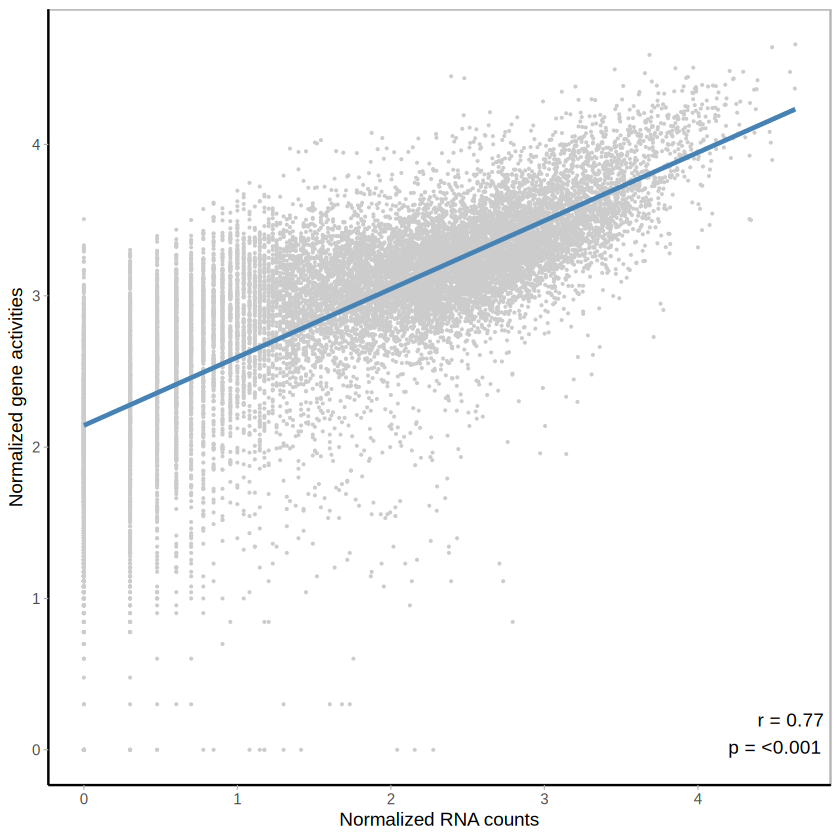

In [14]:
#fig3g
rna.dt <- AggregateExpression(EC, assays = 'RNA',group.by = 'subtype')[[1]]
act.dt <- AggregateExpression(EC, assays = 'activity',group.by = 'subtype')[[1]]
genes.dt <- intersect(row.names(rna.dt),row.names(act.dt))
p.dt <- data.frame(rna = rowSums(rna.dt[genes.dt,]),activities = rowSums(act.dt[genes.dt,]))
cor_value <- cor.test(log10(p.dt$rna + 1), log10(p.dt$activities + 1))
r <- round(cor_value$estimate, 3)
p_value <- scales::pvalue(cor_value$p.value)
p<-ggplot(data = p.dt, mapping = aes(x = log10(rna+1), y = log10(activities+1))) +
 geom_point(color='gray80', size=0.1) +
 geom_smooth(method = "lm", color = "#4682B4", formula = y ~ x) + # add linear regression line
 theme_light() +
 theme(
 panel.grid.major = element_blank(),
 panel.grid.minor = element_blank(),
 axis.line = element_line(color = "black"),
 legend.position = 'none'
 ) +
 xlab('Normalized RNA counts') + # fix axis label
 ylab('Normalized gene activities') +
 annotate("text", 
 x = Inf, y = 0, # place text in upper-right corner
 label = paste0("r = ", r, "\n", "p = ", p_value), 
 hjust = 1.1, vjust = 0.1, # fine-tune text position
 size = 4, color = "black")
ggsave(plot = p, filename = "fig3g.pdf",path = "plot/figure3/", width = 3, height = 3)
p

In [20]:
#fig3h
library(ggraph)
library(tidygraph)
library(igraph)
library(ggplot2)
library(FigR)
library(dplyr)
figR.d <- readRDS("data/EC2_figR.bak.rds")
rank.p <- rankDrivers(figR.d,rankBy = "meanScore",myLabels = c("Stat3","Pparg","Klf4","Klf5","Klf3","Klf13"))
rank <- rank.p$data
rank.p$data$TF <- ""
p <- rank.p+ggrepel::geom_text_repel(
 aes(label = TF),
 rank,
 max.overlaps = 200,
 box.padding = 0.5,
 min.segment.length = 0.5,
 ylim = c(0.005, NA),
 force = T
)
ggsave(plot = p, filename = "fig3h.pdf",path = "results/figure3/", width = 3.5, height = 3)


Ranking TFs by mean regulation score across all DORCs ..


Warning message in geom_bar(size = 0.1, stat = "identity", fill = "darkorange", :
“Ignoring unknown parameters: `size`”


In [7]:
rank$Motif

[1] Stat3    Pparg    Nr2f6    Klf4     Smad4    Hmg20a   Tbx6     Stat5b  
  [9] Mlxip    Nr3c1    Lin54    Hic2     Nr2c1    Pbx2     Klf5     Gata3   
 [17] Nfia     Zkscan6  Ebf2     Trps1    Tcf12    Cebpb    Zfp324   Taf1    
 [25] Tead1    Zfp652   Prdm4    Esrra    Pbx3     Klf3     Foxn2    Rest    
 [33] Nr2f2    Creb3l1  Npas2    Gata4    Zfp41    Nfe2l2   Ybx3     Gata6   
 [41] Hoxb4    Tbp      Hif1a    Meis2    Mef2b    Myc      Nfkb1    Ar      
 [49] Zeb2     Rora     Esrrg    Tbx5     Zfp711   Foxp2    Irf2     Nr4a1   
 [57] Tbx2     Borcs8   Ahctf1   Lbx2     Zfp64    Pbx1     Zfp189   Glis3   
 [65] Sox4     Stat6    Zfp174   Patz1    Bbx      Klf13    Glis2    Usf2    
 [73] Zfp110   Setbp1   Tbx20    Cebpg    Junb     Bcl6     Nr1d1    Zfp768  
 [81] Zfp335   Zfp410   Zfp692   Klf9     Zbtb1    Tcf7     Prdm9    Hnf4a   
 [89] Nfic     Zfp212   Nfatc1   Ebf4     Zfp202   Cbfb     Zkscan1  E2f6    
 [97] Nfatc2   Plagl1   Fosb     Zbtb43   Lyl1     Tead4    Mlxipl   Shox2   
[105] Elk4     Foxj2    Stat5a   Zfp740   Vezf1    Rfx1     Hoxa3    Obox1   
[113] Zfp282   Mafk     Zfp90    Atf6b    Ddit3    Arid5b   Sox18    Nfatc3  
[121] Zfp637   Arid3a   Hdx      Mitf     Sox30    Lcor     Yy1      Crebzf  
[129] Zbtb48   Hey1     Snai2    Esr1     Tgif1    Zfp287   Dmrt1    Alx4    
[137] Rbpj     Zfp3     Tcf21    Nfix     Zfp105   Zfp24    Nr5a2    Zbtb20  
[145] Rarb     Foxk2    Zbtb7a   Sox17    Runx1    Zfp787   Pou2f3   Sox5    
[153] Hbp1     Zbtb26   Maf      Dbp      Ikzf1    Hand2    Klf6     Ubp1    
[161] Arnt2    Thap11   Bsx      Runx3    Klf10    Hoxb6    Fbxl19   Zfp566  
[169] Zbtb3    Prrx1    Zfx      Mecom    Zfp777   Mef2a    Nr2e3    Meox2   
[177] Klf7     Gmeb1    Rxrb     Foxf1    Nfatc4   Meis1    Hoxa7    Sox11   
[185] Nfat5    Hmbox1   Pou4f1   Hsf1     Tfap2c   Thrb     Vdr      Tfeb    
[193] Xbp1     Fosl1    Rhox8    Rara     Usf1     Bhlhe41  Cxxc4    Mybl2   
[201] Tfcp2    Zfp113   Irx6     Hoxd3    Zfp128   Lhx4     Pax6     Cxxc5   
[209] Zscan29  Foxc2    Zfp524   Zfp46    Pou3f2   Zzz3     Nfe2     Sox6    
[217] Tfap2a   Nr1d2    Nhlh2    Cdc5l    Zfp281   E2f5     Aire     Gbx1    
[225] Zfp771   Mafg     Klf12    Twist2   Irf1     Hoxa4    Sp110    Zscan20 
[233] Zfp647   E2f4     Zfp384   Kmt2a    Emx2     Mxi1     Zkscan17 Trp73   
[241] Dlx4     Tet3     Nkx62    Foxo6    Msx1     Zfp354b  Pitx2    Zfp653  
[249] Zik1     Zbtb12   Pax5     Gli3     Six3     Hoxb2    Kdm2b    Foxp3   
[257] Hmga2    Zfp784   Six4     Zeb1     Creb5    Zfp879   Klf2     Zic4    
[265] Msc      Atf4     Barx2    Zbtb14   Fosl2    Six1     Grhl2    Scrt2   
[273] Tbr1     Spic     Hoxb9    Hsf3     Pax2     Prrx2    Lin28a   Pou6f2  
[281] Mbd2     Esrrb    Bcl6b    Tgif2    Srebf2   Dpf3     Ppara    Lef1    
[289] Cdx1     Crebl2   Irx2     Foxc1    Hoxd8    Spdef    Fos      Tbx18   
[297] Cxxc1    Lin28b   Atf2     Rfx8     Dlx2     Irx3     Creb3    Ovol1   
[305] Spi1     Hoxa6    Obox3    Lcorl    Tef      Zfp454   Nfya     Runx2   
[313] Bhlha15  Mypop    Pitx3    Trp63    Elf1     Zfp382   Pou6f1   Tbx21   
[321] Dmrta2   Nr1i3    Etv6     Dnmt1    Hoxa10   Cux2     Hsf4     Hoxc8   
[329] Zfp184   Etv1     Ctcfl    Elk3     Erf      Ets1     Etv3     Etv4    
[337] Etv5     Gabpa    Grhl1    Prdm11   Sp1      Sp140    Ctcf     Zbtb33  
[345] Fli1     Zfp300   Prox2    Foxn1    Tfe3     Isl2     Creb1    Nrf1    
[353] Dmbx1    Ehf      Hes7     Nfil3    Srebf1   Zfp13    Elf2     Hmga1   
[361] Tbx15    Ahr      Zbtb49   Hoxc9    Irf9     Hoxd4    Tal2     Irf6    
[369] Atoh7    Klf11    E2f3     Elf4     Zbtb18   Snai1    Sp9      Zfp661  
[377] Sp100    Egr1     Foxm1    Mlx      Mtf1     Smad5    Zfp641   Hoxa5   
[385] Smad1    Elk1     Pknox1   Foxa3    Sp6      Zic2     Prdm6    Sp2     
[393] Mynn     Pou1f1   Hoxa2    Onecut1  Lhx8     Zfp558   Hnf1b    Mycn    
[401] Stat1    Pitx1    Egr3     Hlf      Irx1     Bcl11b   Tcf7l2   Rfx6    
[409] Zfp354a  Foxo4    

In [84]:
library(Hmisc)
library(Signac)
library(FigR)
library(BSgenome.Mmusculus.UCSC.mm10)
library(BiocParallel)
obj <- subset(subsc.list[[3]],subtype %in% c("EC-1","EC-2"))
obj[["aUCell"]] <- readRDS("data/ac_AUCell.Rds")[,colnames(obj)][["AUCell"]]
obj[["motif"]] <- readRDS("data/motif.Rds")[,colnames(obj)][["motif"]]
DefaultAssay(obj) <- 'motif'
ranklist <- rankDrivers(figR.d,rankBy = "meanScore")$data
rownames(ranklist) <- ranklist$Motif
DefaultAssay(obj) <- 'aUCell'
obj[["aUCell"]] <- as(obj[["aUCell"]],Class = "Assay5")
rownames(obj) <- tolower(gsub("-", " ", gsub("GOBP-", "", rownames(obj))))

Ranking TFs by mean regulation score across all DORCs ..


Warning message in geom_bar(size = 0.1, stat = "identity", fill = "darkorange", :
“Ignoring unknown parameters: `size`”
Warning message:
“Setting row names on a tibble is deprecated.”
Warning message:
“Assay aUCell changing from Assay to Assay5”
Warning message:
“Renaming features in v3/v4 assays is not supported”


In [85]:
dt <- data.frame(t(GetAssayData(obj,assay = 'motif',layer = 'data')[ranklist$Motif,]),
 cardiac = GetAssayData(obj,assay = 'aUCell',layer = 'data')['endothelial cell migration',])
res <- rcorr(as.matrix(dt),type	= 'pearson')
res_p <- res$P
plot.dt <- data.frame(score = ranklist[colnames(dt),]$Score,cor_r= res$r[,'cardiac'],genes = colnames(dt) )
plot.dt$color <- ifelse(plot.dt$genes %in% c("Klf4"),'ERR','Others')
esrra_data<- subset(plot.dt, genes %in% c('Klf4','Stat3','Pparg','Nr2f6'))
p <- ggplot(data = plot.dt, mapping = aes(x = score, y = cor_r, color = color)) +
 geom_point(aes(alpha = 0.5)) +
 xlim(-0.3, 0.3) +
 ylim(-0.5, 0.5) +
 theme_light() +
 geom_text_repel(
 data = esrra_data, # subset data
 aes(label = genes), # label content
 color = "black", # labelcolors(distinct from points)
 nudge_x = 0.02, # horizontal offset
 nudge_y = 0.02, # vertical offset
 size = 4,)+
 scale_color_manual(values = c('#C65762','#444576')) +
 theme(
 panel.grid.major = element_blank(), # remove major gridlines
 panel.grid.minor = element_blank(), # remove minor gridlines
 axis.line = element_line(color = "black"),
 legend.position = 'None') +
 xlab('Regulation score')+ylab('Pearson correlation coefficient \n (Motif activities vs endothelial cell migration)')
ggsave(plot = p, filename = "fig3i.pdf",path = "plot/figure3/", width = 4.5, height =4,create.dir = T) 

Warning message:
“Removed 202 rows containing missing values or values outside the scale range
(`geom_point()`).”


In [86]:
dt <- data.frame(t(GetAssayData(obj,assay = 'motif',layer = 'data')[ranklist$Motif,]),
 cardiac = GetAssayData(obj,assay = 'aUCell',layer = 'data')['sprouting angiogenesis',])
res <- rcorr(as.matrix(dt),type	= 'pearson')
res_p <- res$P
plot.dt <- data.frame(score = ranklist[colnames(dt),]$Score,cor_r= res$r[,'cardiac'],genes = colnames(dt) )
plot.dt$color <- ifelse(plot.dt$genes %in% c("Klf4"),'ERR','Others')
esrra_data<- subset(plot.dt, genes %in% c('Klf4','Stat3','Pparg','Nr2f6'))
p <- ggplot(data = plot.dt, mapping = aes(x = score, y = cor_r, color = color)) +
 geom_point(aes(alpha = 0.5)) +
 xlim(-0.3, 0.3) +
 ylim(-0.5, 0.5) +
 theme_light() +
 geom_text_repel(
 data = esrra_data, # subset data
 aes(label = genes), # label content
 color = "black", # labelcolors(distinct from points)
 nudge_x = 0.02, # horizontal offset
 nudge_y = 0.02, # vertical offset
 size = 4,)+
 scale_color_manual(values = c('#C65762','#444576')) +
 theme(
 panel.grid.major = element_blank(), # remove major gridlines
 panel.grid.minor = element_blank(), # remove minor gridlines
 axis.line = element_line(color = "black"),
 legend.position = 'None') +
 xlab('Regulation score')+ylab('Pearson correlation coefficient \n (Motif activities vs sprouting angiogenesis)')
ggsave(plot = p, filename = "fig3j.pdf",path = "plot/figure3/", width = 4.5, height =4,create.dir = T) 

Warning message:
“Removed 202 rows containing missing values or values outside the scale range
(`geom_point()`).”
